In [ ]:
from src.utils.config import DATASET_FINAL, RAW_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display


In [52]:
sns.set_theme(style="whitegrid")
def pastel_colors(n):
    return sns.color_palette("pastel", n)

plt.rcParams["figure.figsize"] = (12,6)

In [53]:
data = pd.read_csv(DATASET_FINAL)

In [54]:
print("Total audios:", len(data))

Total audios: 60289


In [55]:
eda = data.copy()

In [56]:
eda.shape

(60289, 20)

In [57]:
eda.head()

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification,alertable
0,1-115545-A-48.wav,/m/0g6b5,NaN,fire,NaN,ESC50/1-115545-A-48.wav,ESC50,train,indefinida,True,True,wav,5.0,44100,Mono,16.0,705600.0,430.71,2026-05-07 22:08:46,True
1,1-115545-B-48.wav,/m/0g6b5,NaN,fire,NaN,ESC50/1-115545-B-48.wav,ESC50,test,indefinida,True,True,wav,5.0,44100,Mono,16.0,705600.0,430.71,2026-05-07 22:08:46,True
2,1-115545-C-48.wav,/m/0g6b5,NaN,fire,NaN,ESC50/1-115545-C-48.wav,ESC50,train,indefinida,True,True,wav,5.0,44100,Mono,16.0,705600.0,430.71,2026-05-07 22:08:46,True
3,1-115546-A-48.wav,/m/0g6b5,NaN,fire,NaN,ESC50/1-115546-A-48.wav,ESC50,train,indefinida,True,True,wav,5.0,44100,Mono,16.0,705600.0,430.71,2026-05-07 22:08:46,True
4,1-137296-A-16.wav,/m/0ngt1,NaN,weather,NaN,ESC50/1-137296-A-16.wav,ESC50,train,exterior,False,True,wav,5.0,44100,Mono,16.0,705600.0,430.71,2026-05-07 22:08:46,False


In [58]:
eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60289 entries, 0 to 60288
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   audio              60289 non-null  object 
 1   label              60289 non-null  object 
 2   labels             51197 non-null  object 
 3   human_label        60289 non-null  object 
 4   human_labels       51197 non-null  object 
 5   path               60289 non-null  object 
 6   dataset_source     60289 non-null  object 
 7   split              60289 non-null  object 
 8   env                54744 non-null  object 
 9   emergency          54744 non-null  object 
 10  file_exists        60289 non-null  bool   
 11  audio_format       60289 non-null  object 
 12  duration           60289 non-null  float64
 13  sample_rate        60289 non-null  int64  
 14  channels           60289 non-null  object 
 15  bit_depth          60280 non-null  float64
 16  bit_velocity       602

In [59]:
eda.describe(include="all")

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification,alertable
count,60289,60289,51197,60289,51197,60289,60289,60289,54744,54744,60289,60289,60289.000000,60289.000000,60289,60280.000000,6.028000e+04,60289.000000,60289,60289
unique,60289,206,3255,60,1680,60289,3,2,3,2,1,1,NaN,NaN,2,NaN,NaN,NaN,575,2
top,1-115545-A-48.wav,/m/085jw,"[""/m/085jw"", ""/m/04szw"", ""/m/04rlf""]",guitar,"[""percussion"", ""Musical_instrument"", ""music""]",ESC50/1-115545-A-48.wav,zenodo,train,indefinida,False,True,wav,NaN,NaN,Mono,NaN,NaN,NaN,2020-06-16 00:54:28,False
freq,1,2627,2612,4452,3053,1,51197,48240,26894,51250,60289,60289,NaN,NaN,52296,NaN,NaN,NaN,837,48402
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.036624,44731.046178,NaN,16.404512,8.643400e+05,675.967378,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.357719,6021.038357,NaN,1.876884,5.353738e+05,650.907194,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050000,8000.000000,NaN,8.000000,8.820000e+04,5.980000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.110000,44100.000000,NaN,16.000000,7.056000e+05,189.080000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,44100.000000,NaN,16.000000,7.056000e+05,505.400000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.108000,44100.000000,NaN,16.000000,7.056000e+05,924.110000,NaN,NaN


In [60]:
eda.isna().sum().sort_values(ascending=False)

labels               9092
human_labels         9092
env                  5545
emergency            5545
bit_velocity            9
bit_depth               9
audio                   0
duration                0
date_modification       0
size                    0
channels                0
sample_rate             0
file_exists             0
audio_format            0
label                   0
split                   0
dataset_source          0
path                    0
human_label             0
alertable               0
dtype: int64

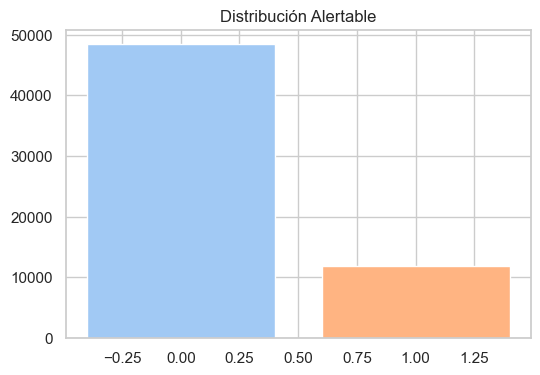

In [61]:
counts = eda["alertable"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    counts.index,
    counts.values,
    color=pastel_colors(len(counts))
)

plt.title("Distribución Alertable")
plt.show()

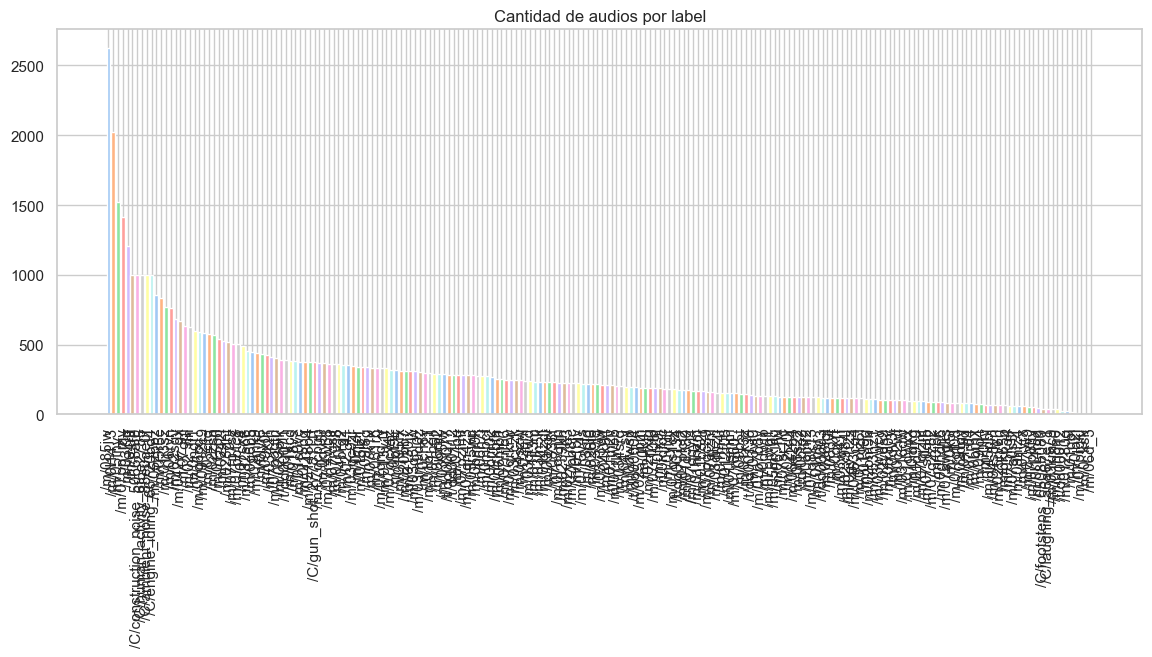

In [62]:
label_counts = eda["label"].value_counts()

plt.figure(figsize=(14,5))

plt.bar(
    label_counts.index,
    label_counts.values,
    color=pastel_colors(len(label_counts))
)

plt.xticks(rotation=90)
plt.title("Cantidad de audios por label")

plt.show()

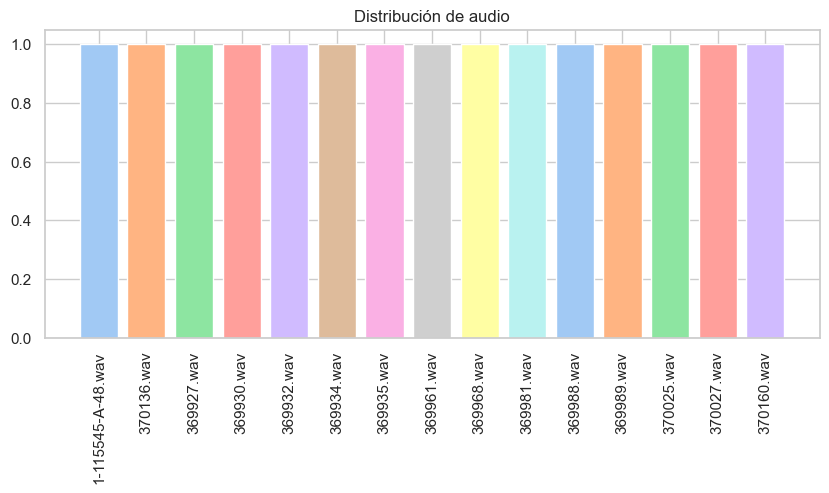

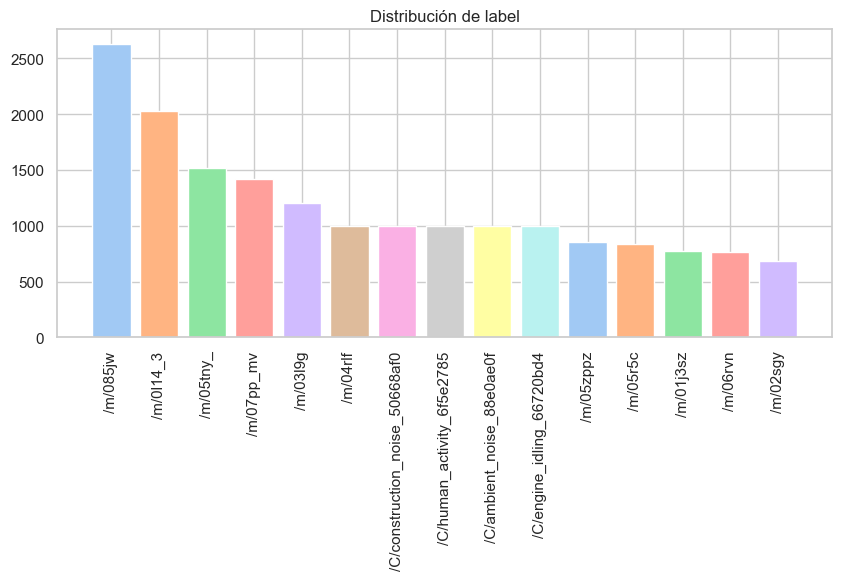

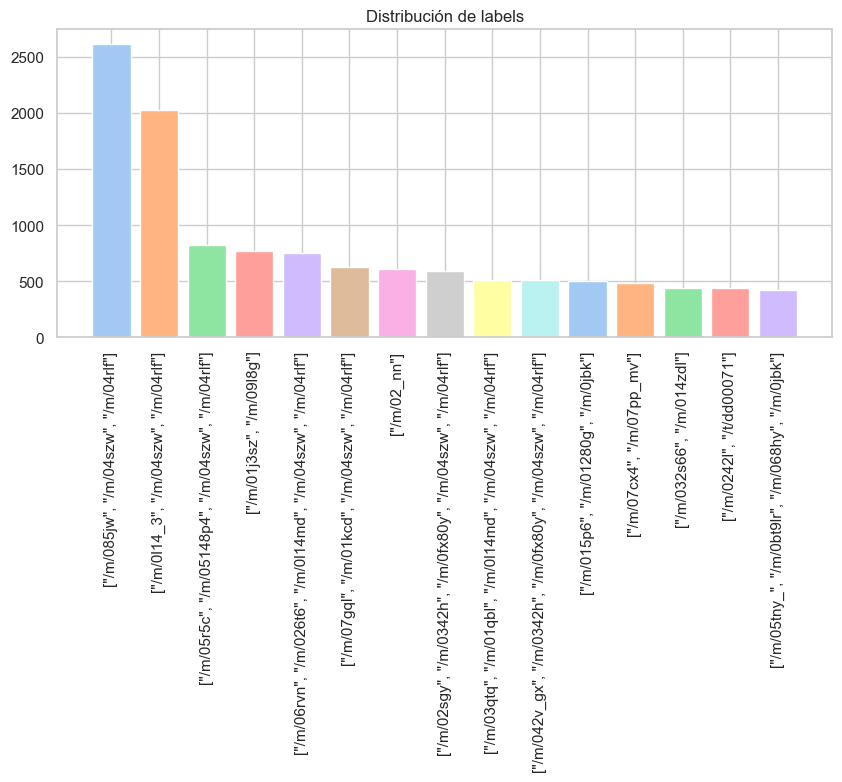

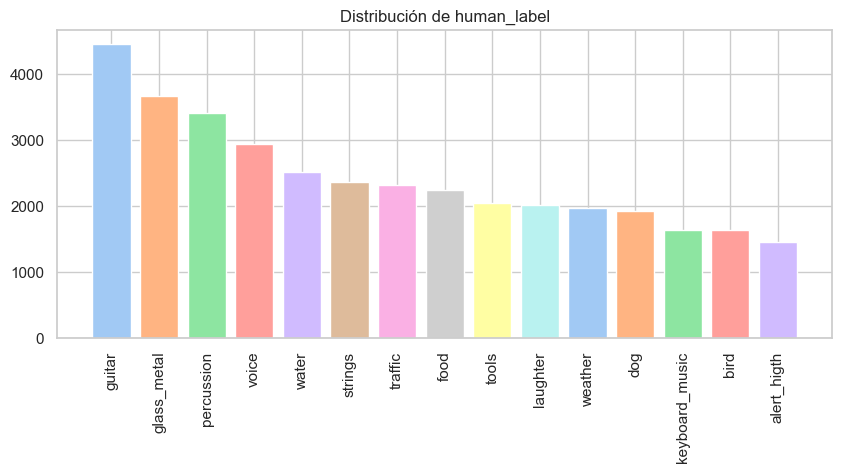

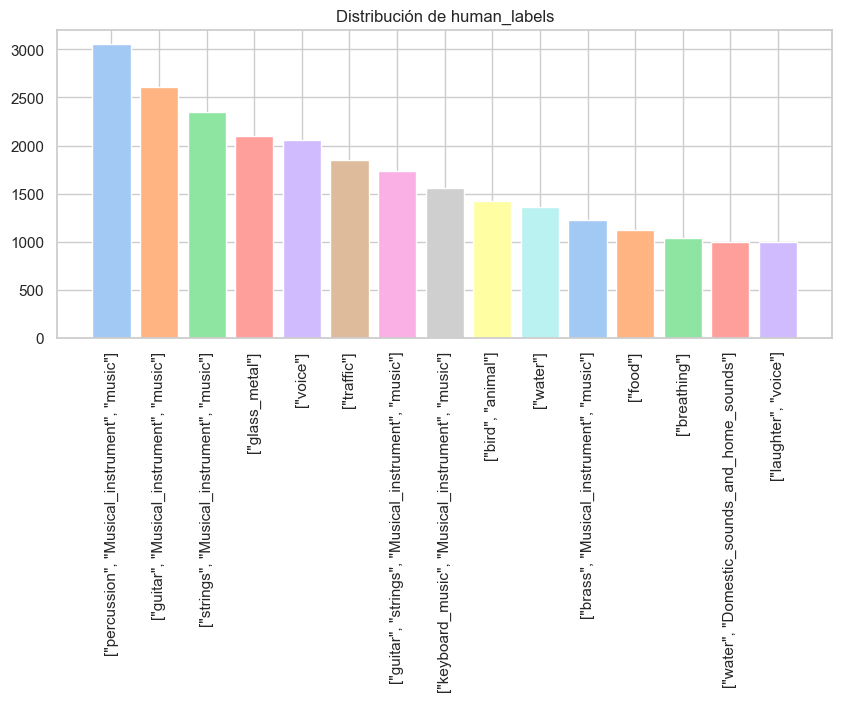

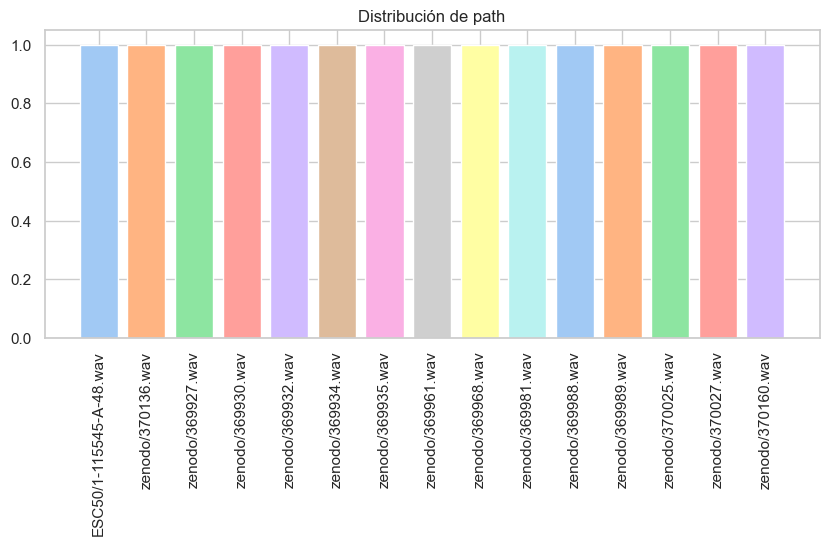

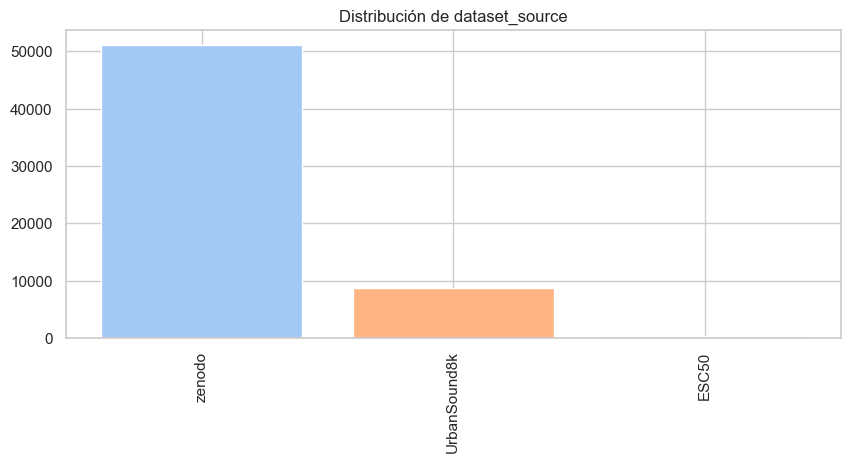

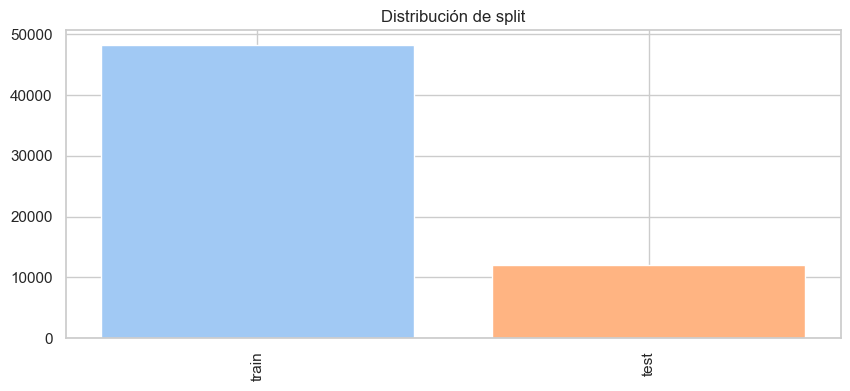

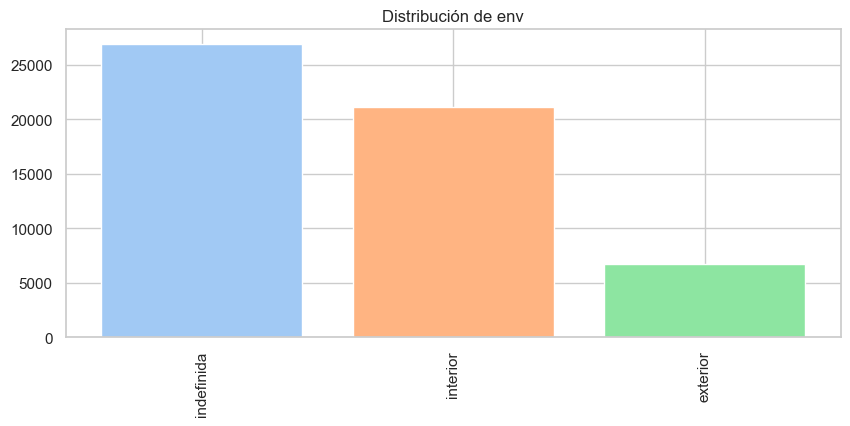

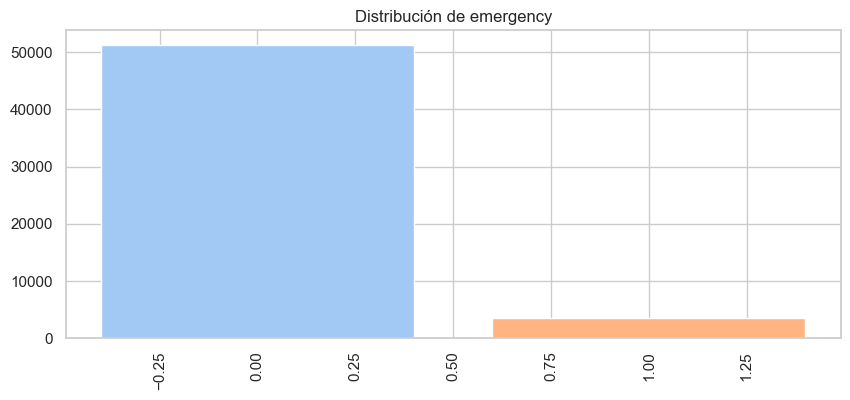

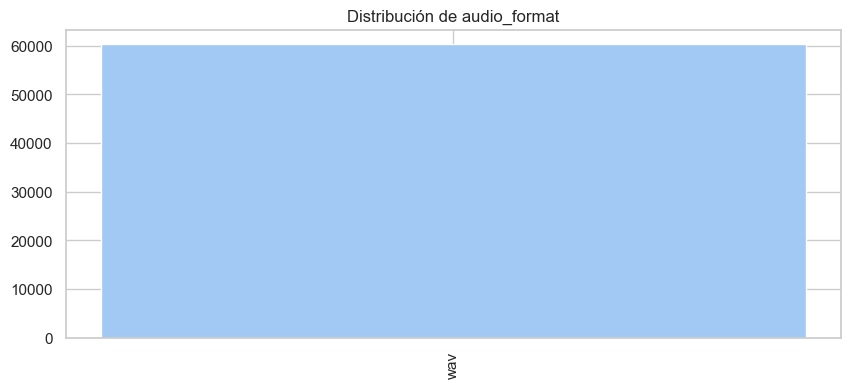

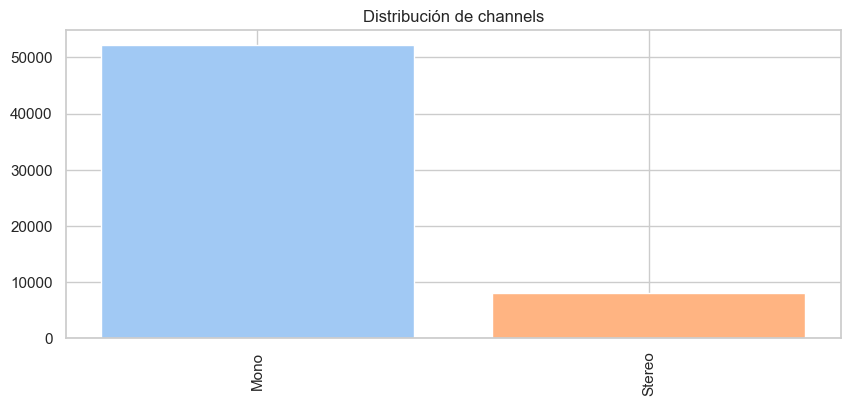

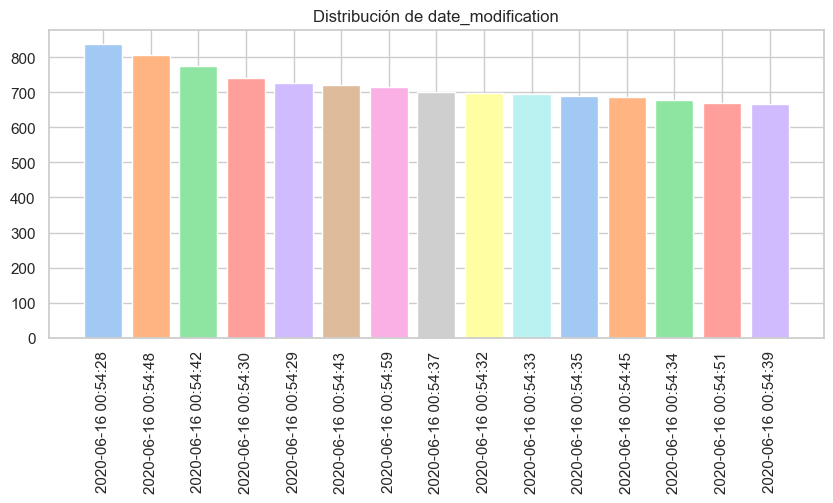

In [63]:
cat_cols = eda.select_dtypes(include="object").columns

for col in cat_cols:

    counts = eda[col].value_counts().head(15)

    plt.figure(figsize=(10,4))

    plt.bar(
        counts.index,
        counts.values,
        color=pastel_colors(len(counts))
    )

    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=90)

    plt.show()

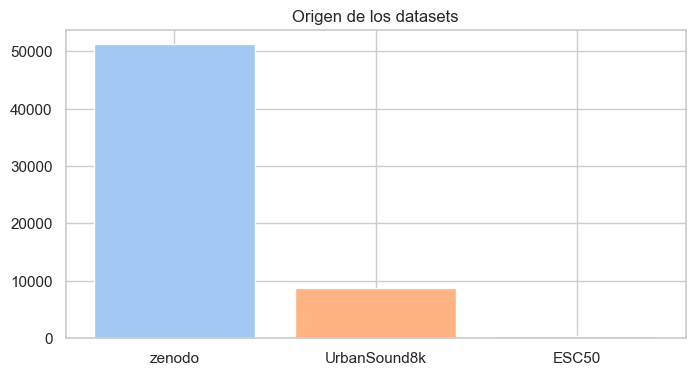

In [64]:
source_counts = eda["dataset_source"].value_counts()

plt.figure(figsize=(8,4))

plt.bar(
    source_counts.index,
    source_counts.values,
    color=pastel_colors(len(source_counts))
)

plt.title("Origen de los datasets")

plt.show()

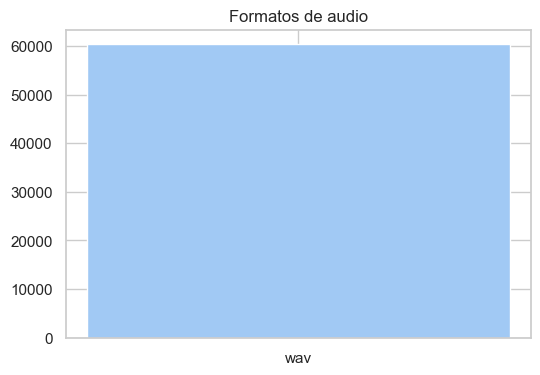

In [65]:
format_counts = eda["audio_format"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    format_counts.index,
    format_counts.values,
    color=pastel_colors(len(format_counts))
)

plt.title("Formatos de audio")

plt.show()

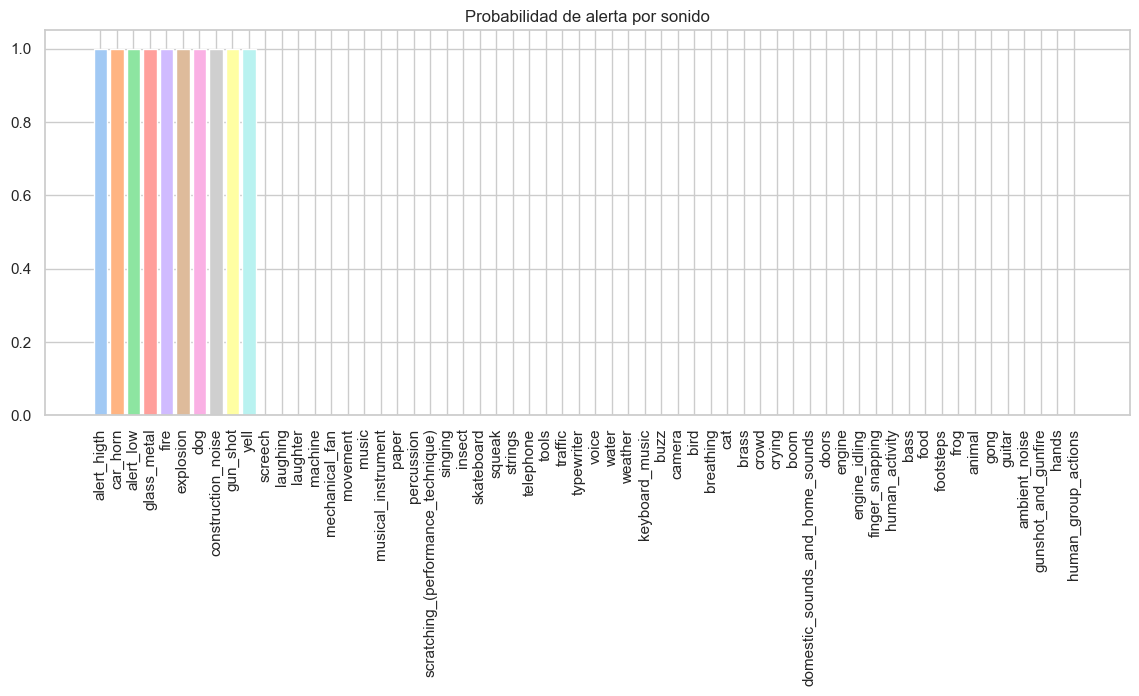

In [68]:
alert_ratio = (
    eda.groupby("human_label")["alertable"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,5))
plt.bar(
    alert_ratio.index,
    alert_ratio.values,
    color=pastel_colors(len(alert_ratio))
)
plt.xticks(rotation=90)
plt.title("Probabilidad de alerta por sonido")
plt.show()

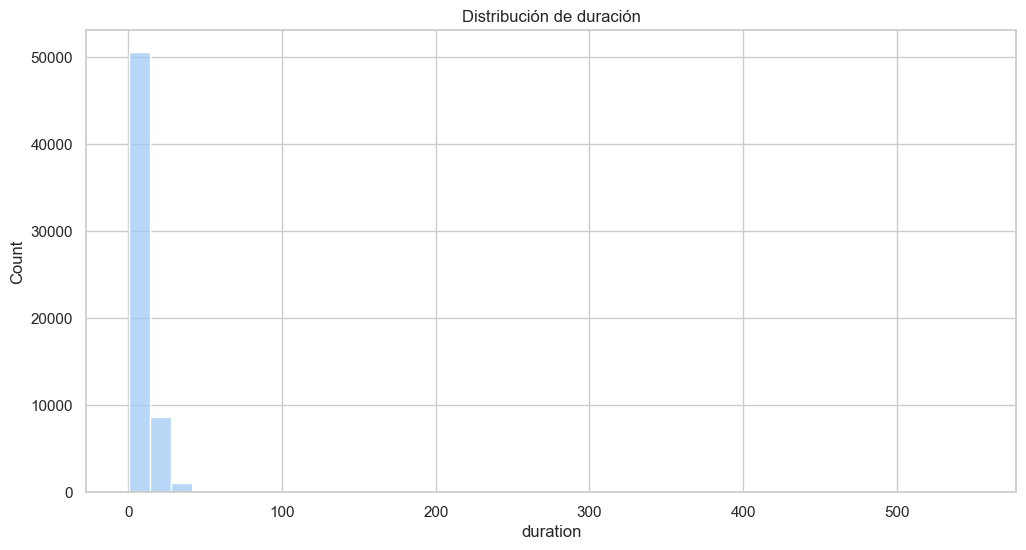

In [70]:
sns.histplot(
    eda["duration"],
    bins=40,
    color=pastel_colors(1)[0]
)
plt.title("Distribución de duración")
plt.show()

In [71]:
numeric_cols = [
    "duration",
    "sample_rate",
    "bit_depth",
    "bit_velocity",
    "size"
]

eda[numeric_cols].describe()

,duration,sample_rate,bit_depth,bit_velocity,size
count,60289.000000,60289.000000,60280.000000,6.028000e+04,60289.000000
mean,7.036624,44731.046178,16.404512,8.643400e+05,675.967378
std,7.357719,6021.038357,1.876884,5.353738e+05,650.907194
min,0.050000,8000.000000,8.000000,8.820000e+04,5.980000
25%,2.110000,44100.000000,16.000000,7.056000e+05,189.080000
50%,4.000000,44100.000000,16.000000,7.056000e+05,505.400000
75%,9.108000,44100.000000,16.000000,7.056000e+05,924.110000
max,550.249000,192000.000000,32.000000,1.228800e+07,47394.570000


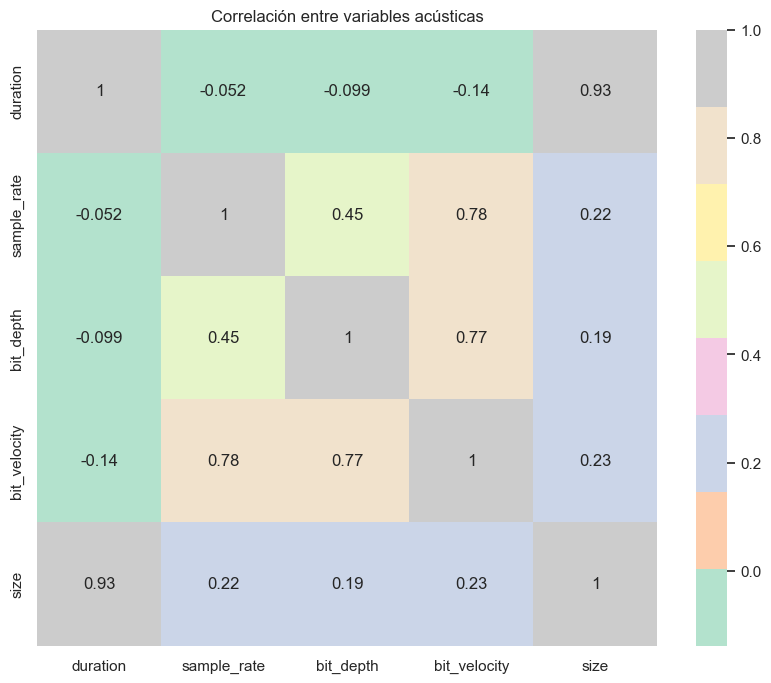

In [72]:
plt.figure(figsize=(10,8))

sns.heatmap(
    eda[numeric_cols].corr(),
    annot=True,
    cmap="Pastel2"
)

plt.title("Correlación entre variables acústicas")
plt.show()

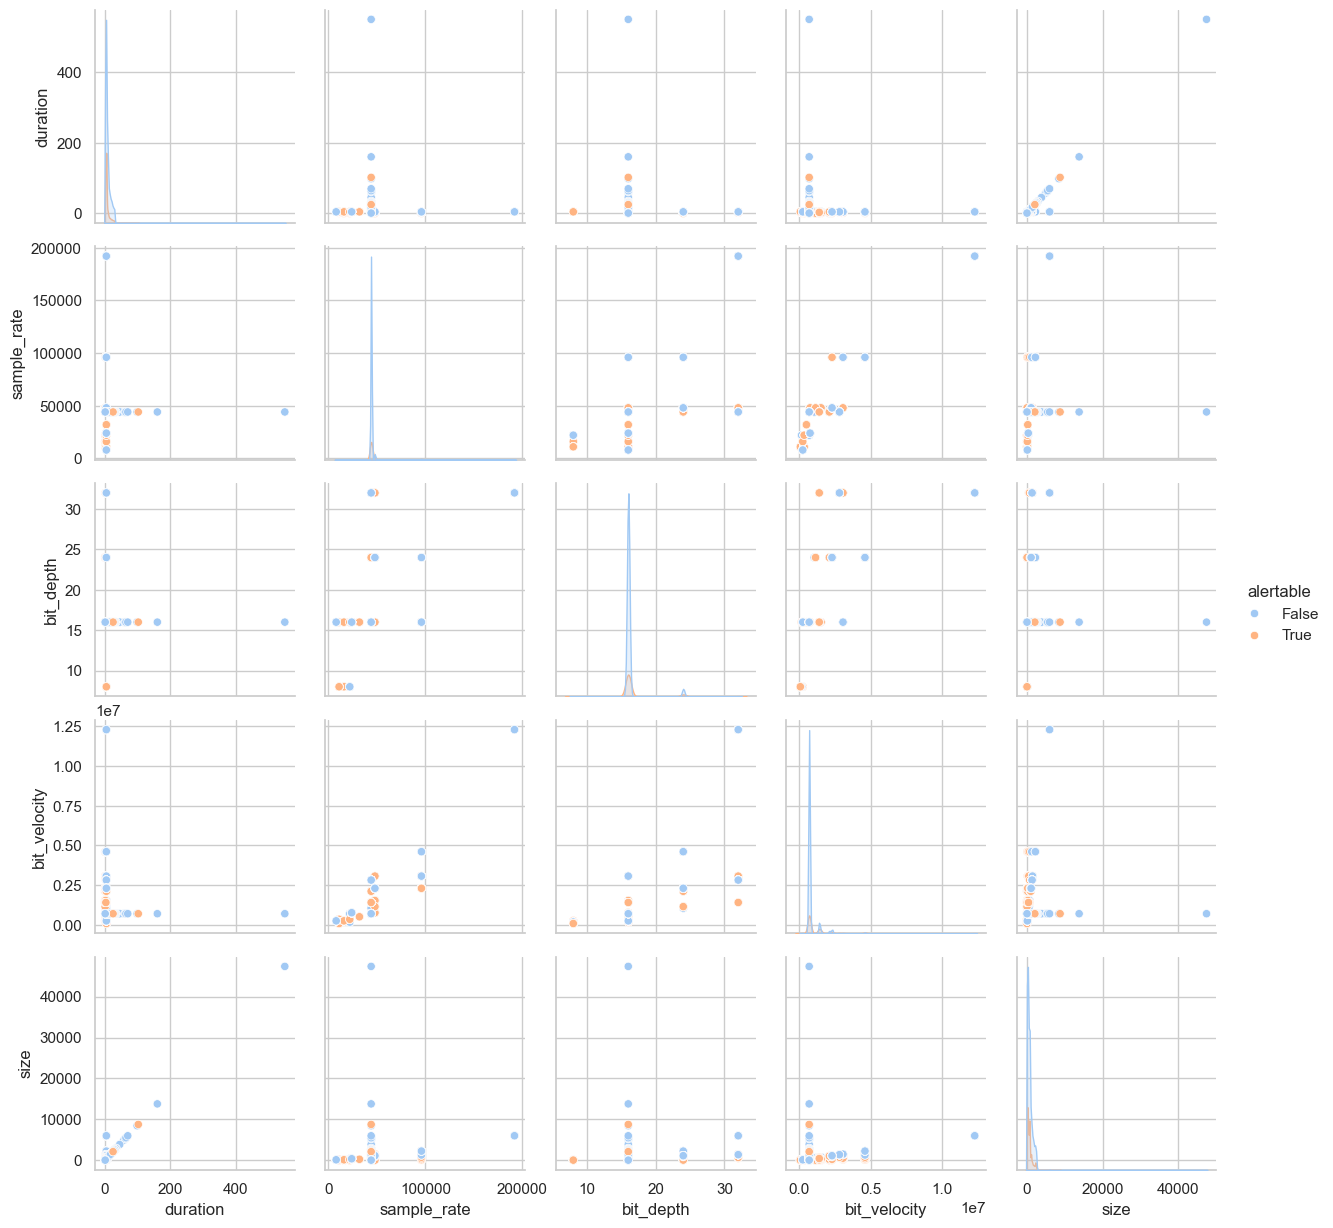

In [73]:
sns.pairplot(
    eda[numeric_cols + ["alertable"]],
    hue="alertable",
    palette="pastel"
)

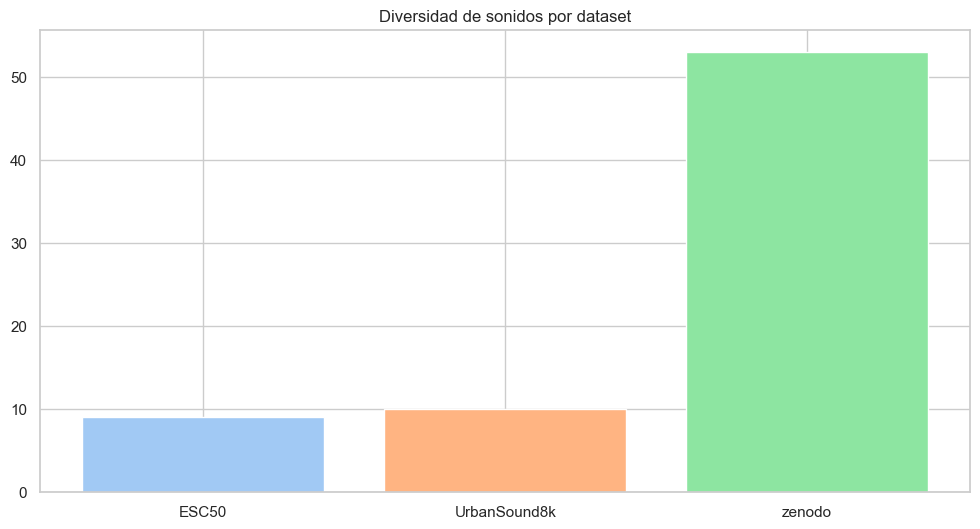

In [74]:
diversidad = eda.groupby("dataset_source")["human_label"].nunique()

plt.bar(
    diversidad.index,
    diversidad.values,
    color=pastel_colors(len(diversidad))
)

plt.title("Diversidad de sonidos por dataset")
plt.show()

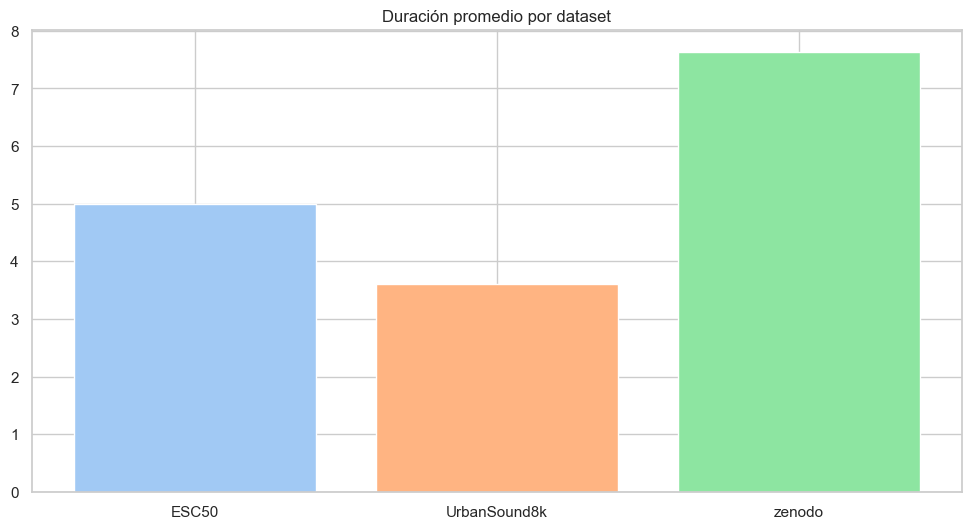

In [75]:
duracion_dataset = eda.groupby("dataset_source")["duration"].mean()

plt.bar(
    duracion_dataset.index,
    duracion_dataset.values,
    color=pastel_colors(len(duracion_dataset))
)

plt.title("Duración promedio por dataset")
plt.show()

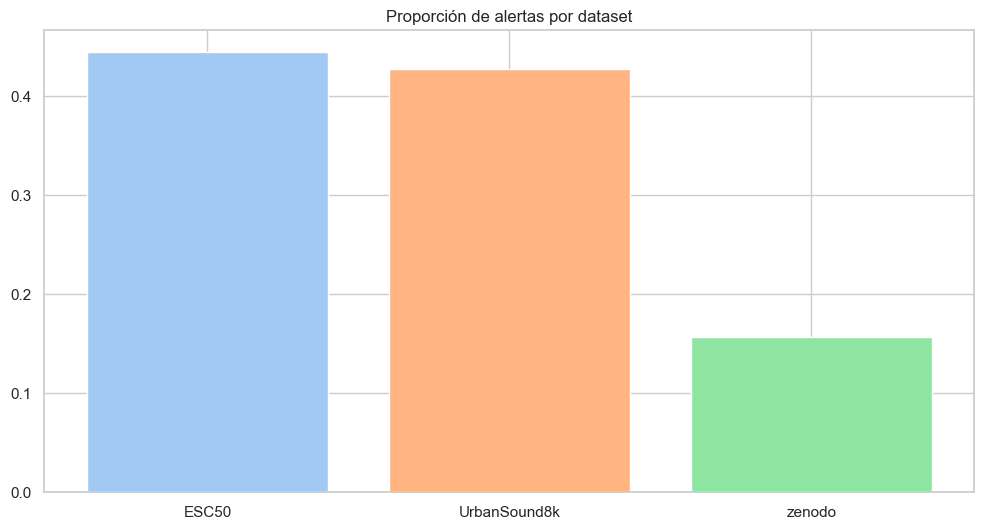

In [76]:
alert_dataset = eda.groupby("dataset_source")["alertable"].mean()

plt.bar(
    alert_dataset.index,
    alert_dataset.values,
    color=pastel_colors(len(alert_dataset))
)

plt.title("Proporción de alertas por dataset")
plt.show()

In [77]:
pd.crosstab(
    eda["env"],
    eda["alertable"],
    normalize="index"
)

alertable,False,True
env,,
exterior,1.000000,0.000000
indefinida,0.714025,0.285975
interior,0.801561,0.198439


# EDA ACÚSTICO — SISTEMA DE ALERTA PARA PERSONAS SORDAS

In [66]:
audio_eda = eda.copy()

In [67]:
sample_path = audio_eda[audio_eda["file_exists"] == True]["path"].iloc[0]
sample_path = RAW_DIR / sample_path
y, sr = librosa.load(sample_path, sr=None)

C:\Users\nata1\AppData\Local\Temp\ipykernel_4332\2768317694.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(sample_path, sr=None)
c:\Users\nata1\Desktop\4geeks\Sistema de alerta\proyecto4geeks\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\nata1\\Desktop\\4geeks\\Sistema de alerta\\proyecto4geeks\\data\\raw\\ESC50\\1-115545-A-48.wav'

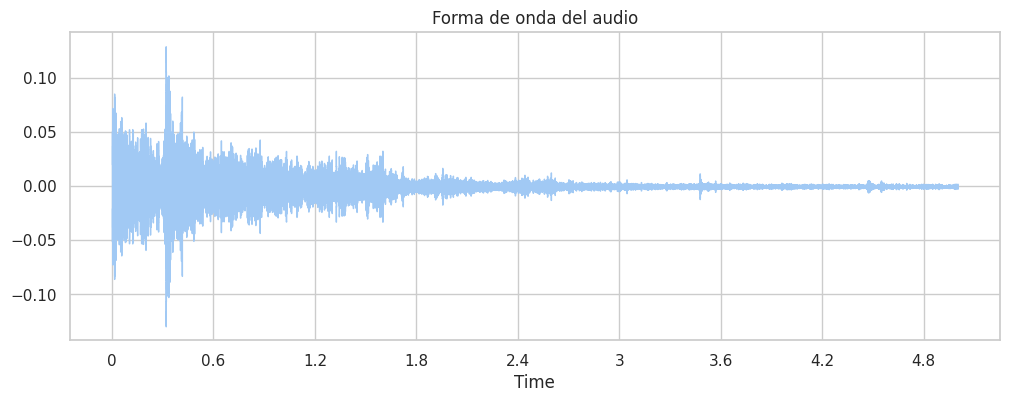

In [ ]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Forma de onda del audio")
plt.show()

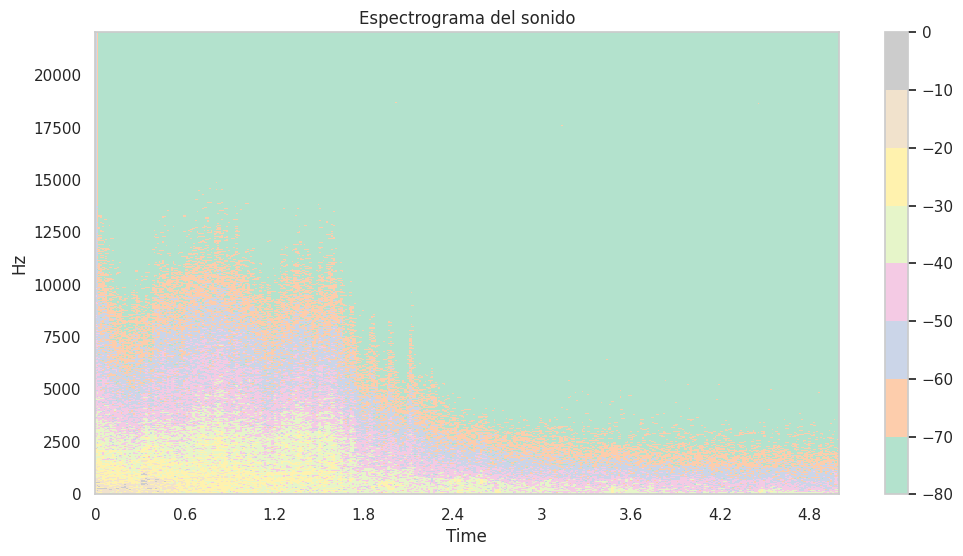

In [ ]:
S = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(12,6))

librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis="time",
    y_axis="hz",
    cmap="Pastel2"
)

plt.colorbar()
plt.title("Espectrograma del sonido")
plt.show()

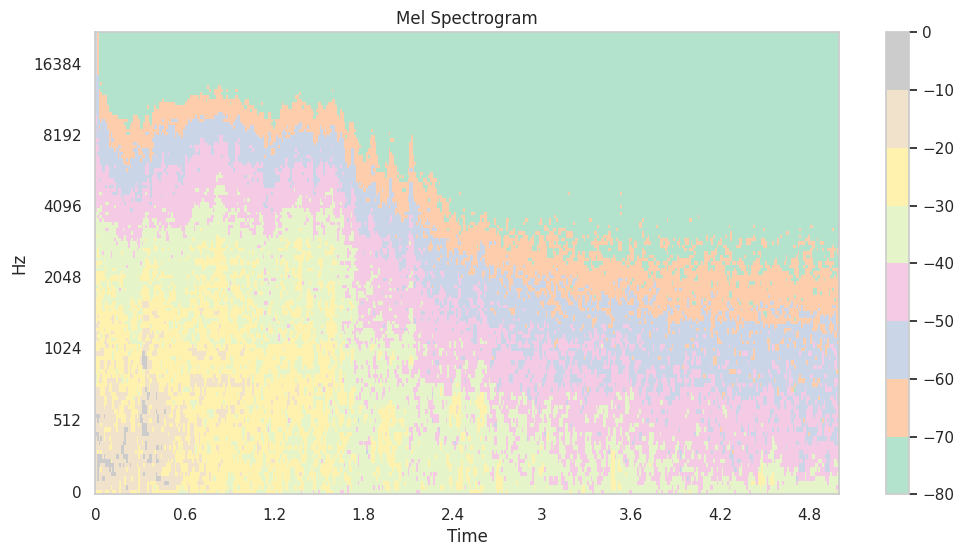

In [ ]:
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12,6))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    cmap="Pastel2"
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

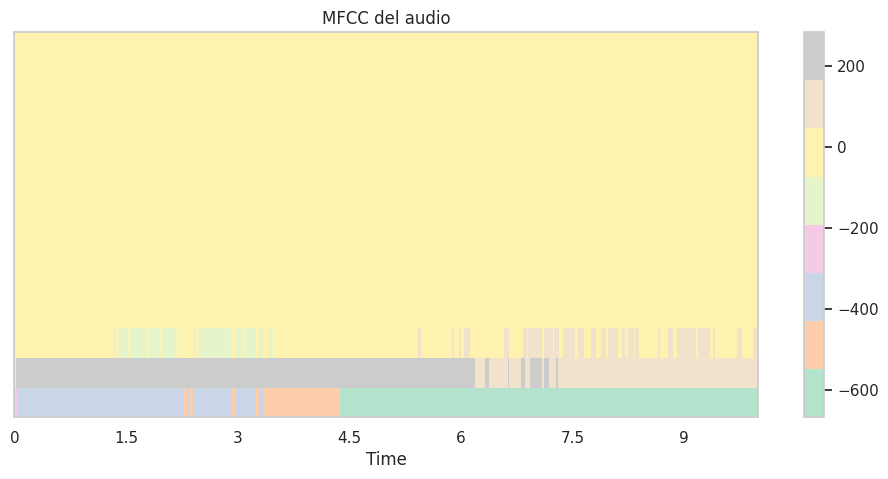

In [ ]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    cmap="Pastel2"
)

plt.colorbar()
plt.title("MFCC del audio")
plt.show()

In [ ]:
def plot_mel_from_label(df, emergency_value):

    sample = df[
        (df["emergency"] == emergency_value) &
        (df["file_exists"] == True)
    ]["path"].iloc[0]
    sample = RAW_DIR / sample
    y, sr = librosa.load(sample, sr=None)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(10,5))

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        cmap="Pastel2"
    )

    plt.title(f"Mel Spectrogram - Emergency={emergency_value}")
    plt.colorbar()
    plt.show()

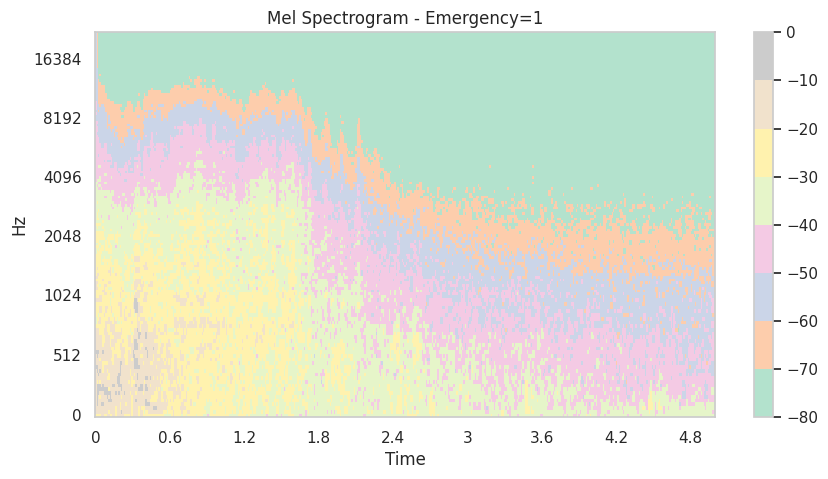

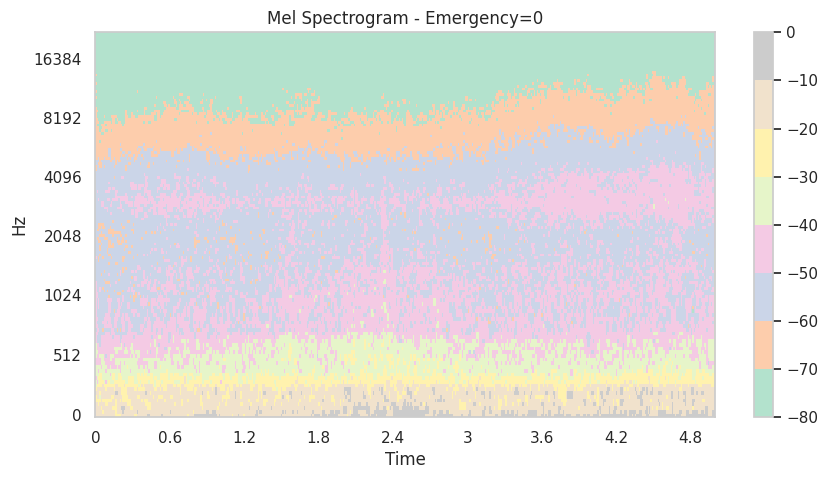

In [ ]:
plot_mel_from_label(audio_eda, 1)
plot_mel_from_label(audio_eda, 0)

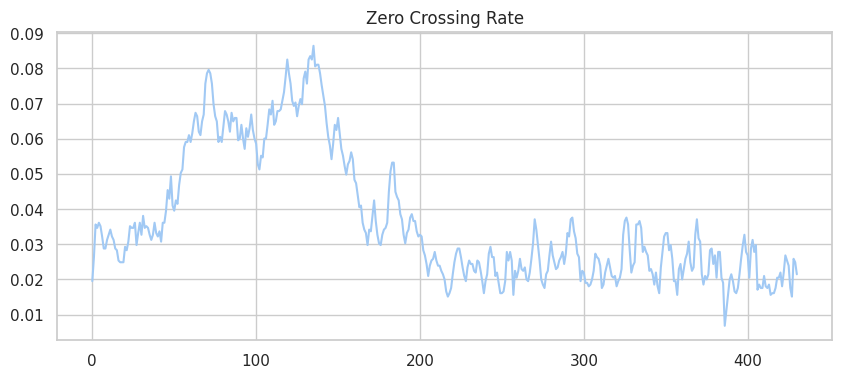

In [ ]:
zcr = librosa.feature.zero_crossing_rate(y)

plt.figure(figsize=(10,4))
plt.plot(zcr[0])
plt.title("Zero Crossing Rate")
plt.show()

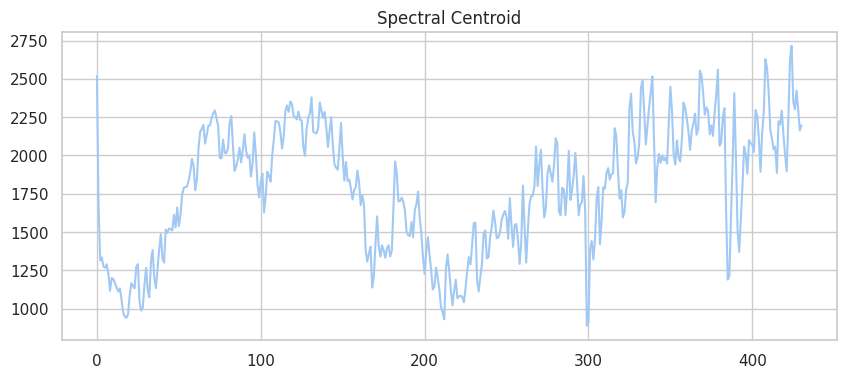

In [ ]:
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

plt.figure(figsize=(10,4))
plt.plot(centroid[0])
plt.title("Spectral Centroid")
plt.show()

In [ ]:
def extract_features(path):
    y, sr = librosa.load(path, sr=None)

    return {
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    }

/tmp/ipykernel_6052/1295868032.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
/home/andres/Documentos/proyecto4geeks/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


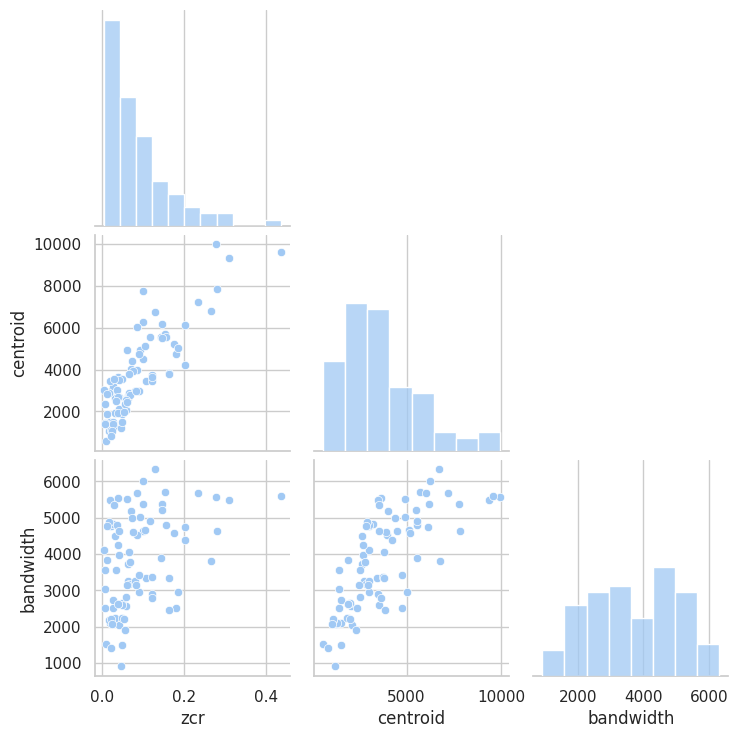

In [ ]:
features = []

for p in audio_eda["path"].sample(100):
    try:
        path = RAW_DIR / p
        features.append(extract_features(path))
    except:
        pass

feat_df = pd.DataFrame(features)

sns.pairplot(feat_df, corner=True)
plt.show()

In [ ]:
eda["human_label"].value_counts()

human_label
guitar                                4452
glass_metal                           3672
percussion                            3410
voice                                 2933
water                                 2513
strings                               2360
traffic                               2319
food                                  2233
tools                                 2038
laughter                              2009
weather                               1972
dog                                   1921
keyboard_music                        1639
bird                                  1634
alert_higth                           1454
alert_low                             1335
breathing                             1323
brass                                 1240
machine                               1238
paper                                 1187
doors                                 1078
music                                 1001
engine_idling                         1000

In [ ]:
df = eda.copy()
label_counts = (
    df["human_label"]
    .value_counts()
    .reset_index()
)

label_counts.columns = ["label", "count"]

label_counts.head()

,label,count
0,guitar,4452
1,glass_metal,3672
2,percussion,3410
3,voice,2933
4,water,2513


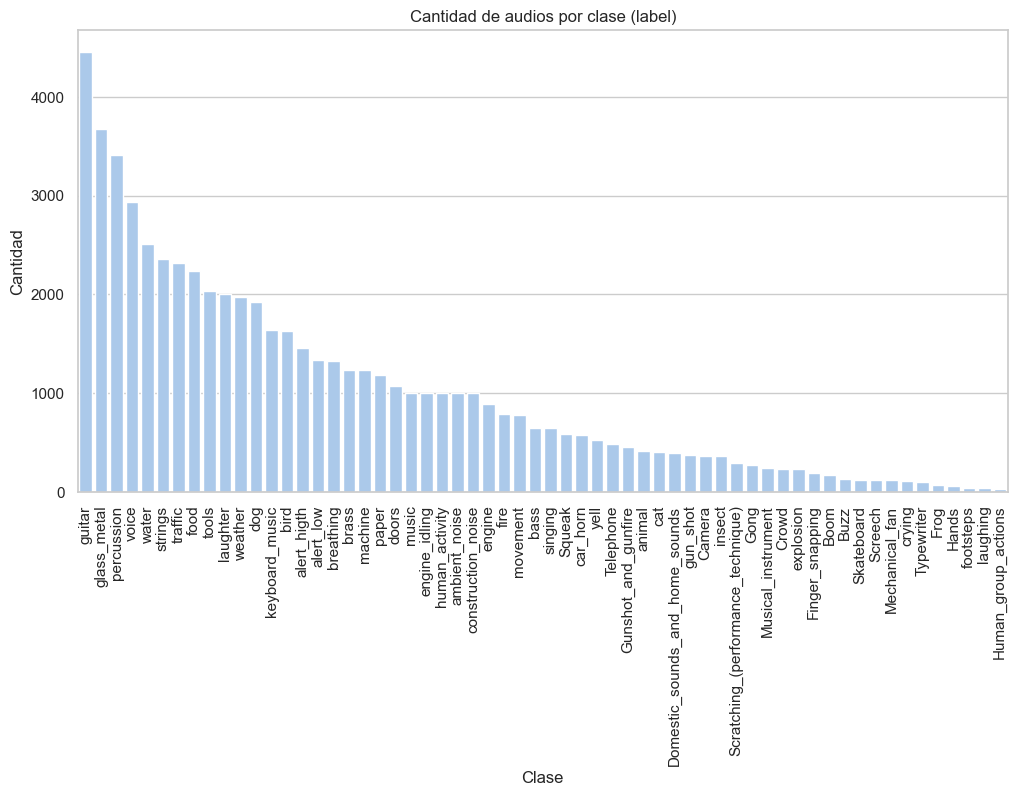

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("pastel")

plt.figure(figsize=(12,6))

sns.barplot(
    data=label_counts,
    x="label",
    y="count"
)

plt.xticks(rotation=90)
plt.title("Cantidad de audios por clase (label)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()